# Reflexive and Verifier Agents

Self-correction loops with a critic LLM and a verifier LLM, built on LangChain + LangGraph.

| Primitive | What it is |
|-----------|------------|
| `Critique` (Pydantic) | Structured critic feedback (weaknesses, suggestions, severity) |
| `Verdict` (Pydantic) | Structured pass/fail verdict with reasons |
| `StateGraph` | LangGraph state-machine container |

We will see how the **draft task** and **drafter LLM** stay fixed across three pipelines (bare draft, critic-loop, verifier-loop) and the quality delta which comes about from "who decides when to stop".

## Setup

Now, we will
- define the **draft task**: write a 4-bullet release note from a list of merged PRs,
- bind a single `MAX_REVISIONS` constant so every loop in the notebook respects the same iteration cap.

In [8]:
# !pip install -q langchain langchain-google-genai langchain-openai langchain-anthropic langgraph langchain-community

from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Optional, Literal
from pydantic import BaseModel, Field
import os, json
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

True

In [9]:
# os.environ['GEMINI_API_KEY']  # the variable for API key

# llm   = init_chat_model('gpt-4o', model_provider='openai', temperature=0)
llm   = init_chat_model('gemini-3.5-flash', model_provider='google_genai', temperature=0)

embed = init_embeddings('sentence-transformers/all-MiniLM-L6-v2', provider='huggingface')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Now the drafting task. We deliberately picked a small, well-scoped task, a 4-bullet release note from a list of merged PRs, so the critic and verifier have something concrete to score and gate on. The PR list carries explicit constraints (exactly 4 bullets, must mention every PR id) that a verifier can check, and subjective qualities (tone, ordering, customer-facing voice) that only a critic can score.

In [15]:
# The drafting task: turn merged PRs into a release-note. WHY this task:
#   - subjective axis (tone, readability, ordering)        -> Critic
#   - objective axis (4 bullets, every PR id appears once) -> Verifier
# The two axes are independent, which is exactly the distinction we want
# the reader to internalize by the end of the notebook.
MERGED_PRS = [
    {'id': 'PR-101', 'title': 'Add streaming responses to /chat endpoint'},
    {'id': 'PR-104', 'title': 'Fix race condition in cache invalidation on logout'},
    {'id': 'PR-107', 'title': 'Bump pydantic to 2.7 and migrate validators'},
    {'id': 'PR-112', 'title': 'New /admin/usage dashboard with per-tenant token counts'},
]

DRAFT_TASK = (
    'Write a customer-facing release note as exactly 4 short bullets, one per merged PR. '
    'Each bullet must reference its PR id (e.g. PR-101) and be no longer than 20 words.'
)

MAX_REVISIONS = 2  # cap shared by every loop in this notebook

print('Draft task    :', DRAFT_TASK)
print('PR count      :', len(MERGED_PRS))
print('MAX_REVISIONS :', MAX_REVISIONS)

Draft task    : Write a customer-facing release note as exactly 4 short bullets, one per merged PR. Each bullet must reference its PR id (e.g. PR-101) and be no longer than 20 words.
PR count      : 4
MAX_REVISIONS : 2


## Bare draft baseline

Let's start with the simplest possible drafter, one LLM call, no critic, no verifier. This is the straw-man the rest of the notebook improves upon.

Now, we will
- define `bare_draft(task, prs)` that calls `llm.invoke()` exactly once,
- run it on the release-note task and print the output,
- name what is missing: there is no quality gate and no correctness gate.

In [19]:
DRAFT_PROMPT = """You are a release-notes writer.

Task: {task}

Merged PRs:
{prs}

Return ONLY the release note. No preamble, no closing remarks.
"""

def _format_prs(prs: List[dict]) -> str:
    """Serialise the PR list into a numbered block. Same format used by every drafter in the notebook so the variable being isolated is the LOOP, not the prompt."""
    return '\n'.join(f"- {p['id']}: {p['title']}" for p in prs)

def _mock_release_note(prs: List[dict]) -> str:
    """Deterministic fallback so the rest of the notebook can run even without a working LLM call.
    Mirrors the shape a real draft would have: one bullet per PR, id + title."""
    return '\n'.join(f"- {p['id']}: {p['title']}." for p in prs)

def bare_draft(task: str, prs: List[dict]) -> str:
    """Single-shot draft. No critic, no verifier, no retries."""
    prompt = DRAFT_PROMPT.format(task=task, prs=_format_prs(prs))
    print("==============")
    print(prompt)
    print("==============")
    try:
        return llm.invoke(prompt).content
    except Exception as e:
        print(f"[bare_draft] LLM call failed ({type(e).__name__}: {e}) — using mock response instead.")
        return _mock_release_note(prs)

bare = bare_draft(DRAFT_TASK, MERGED_PRS)
print('---- BARE DRAFT ----')
print(bare)

You are a release-notes writer.

Task: Write a customer-facing release note as exactly 4 short bullets, one per merged PR. Each bullet must reference its PR id (e.g. PR-101) and be no longer than 20 words.

Merged PRs:
- PR-101: Add streaming responses to /chat endpoint
- PR-104: Fix race condition in cache invalidation on logout
- PR-107: Bump pydantic to 2.7 and migrate validators
- PR-112: New /admin/usage dashboard with per-tenant token counts

Return ONLY the release note. No preamble, no closing remarks.

[bare_draft] LLM call failed (GoogleRateLimitError: Error calling model 'gemini-3.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/gener

The bare draft usually looks plausible. But nothing checked that there are exactly 4 bullets, that every PR id appears, or that the tone is customer-facing. Single-shot has no quality gate and no correctness gate. We will fix that first with a **critic**, then with a **verifier**.

## Critic agent

Now let's add a **critic LLM** that reads the draft, names specific weaknesses, and proposes a rewrite directive. The critic is a coach: it is subjective, it produces structured feedback, and it pushes quality up.

Now, we will
- define a `Critique` Pydantic schema (`weaknesses`, `suggestions`, `severity`),
- bind a `critic_llm` via `with_structured_output(Critique)` so the LLM returns a typed object,
- write `critic_node(draft, task)` that produces the critique and `revise_node(draft, critique, task)` that rewrites,
- run a self-correction loop capped by `MAX_REVISIONS` and print each pass.

In [20]:
class Critique(BaseModel):
    """Structured critic feedback. WHY Pydantic: a typed object plugs straight
    into the revise step instead of regex over free text."""
    weaknesses: List[str] = Field(
        description='Concrete weaknesses in the draft (1-3 items, no praise).')
    suggestions: List[str] = Field(
        description='Concrete edit directives the rewrite step must follow (1-3 items).')
    severity: Literal['minor', 'major'] = Field(
        description="'minor' if the draft only needs polish, 'major' if a real rewrite is needed.")

critic_llm = llm.with_structured_output(Critique)

The schema **drives the loop**. `severity` is a `Literal[...]` so the graph can branch on it stably; `suggestions` is what gets pasted into the revision prompt, so it must read as edit directives, not score rationale.

In [22]:
CRITIC_PROMPT = """You are a senior release-notes editor.

Task the writer was given: {task}

Merged PRs:
{prs}

Draft to critique:
---
{draft}
---

Critique the draft on SUBJECTIVE quality (tone, ordering, customer-facing voice, clarity).
Return concrete weaknesses and concrete rewrite suggestions. Do NOT count bullets or check ids - that is the verifier's job.
"""

def critic_node(draft: str, task: str, prs: List[dict]) -> Critique:
    """Score subjective quality of the draft. NOT a correctness checker; that is the verifier."""
    prompt = CRITIC_PROMPT.format(task=task, prs=_format_prs(prs), draft=draft)
    print("==============")
    print(prompt)
    print("==============")
    return critic_llm.invoke(prompt)

Now the rewrite step. The critic's `suggestions` list. Without it, "rewrite this" becomes a vague instruction the LLM can ignore. With it, the rewrite has a concrete target.

In [24]:
REVISE_PROMPT = """You are a release-notes writer revising your prior draft.

Task: {task}

Merged PRs:
{prs}

PRIOR DRAFT:
---
{draft}
---

Editor weaknesses : {weaknesses}
Editor suggestions: {suggestions}

Return ONLY the improved release note.
"""

def revise_node(draft: str, critique: Critique, task: str, prs: List[dict]) -> str:
    """Rewrite using the critic's suggestions. Reuses the same drafter LLM so
    the variable being isolated is the FEEDBACK, not a smarter model."""
    prompt = REVISE_PROMPT.format(
        task=task, prs=_format_prs(prs), draft=draft,
        weaknesses=critique.weaknesses, suggestions=critique.suggestions,
    )
    print("==============")
    print(prompt)
    print("==============")
    return llm.invoke(prompt).content

And the critic-driven self-correction loop. We critique, then revise, until the critic returns `severity='minor'` or we hit the `MAX_REVISIONS` cap.

In [25]:
def critic_loop(task: str, prs: List[dict], max_revisions: int = MAX_REVISIONS) -> dict:
    """draft -> (critique -> revise) up to max_revisions, or stop early on minor severity."""
    draft = bare_draft(task, prs)
    history = [{'iter': 0, 'draft': draft, 'critique': None}]
    for it in range(1, max_revisions + 1):
        critique = critic_node(draft, task, prs)
        if critique.severity == 'minor':
            history.append({'iter': it, 'draft': draft, 'critique': critique.model_dump()})
            return {'final_draft': draft, 'history': history, 'stopped': 'minor_severity'}
        draft = revise_node(draft, critique, task, prs)
        history.append({'iter': it, 'draft': draft, 'critique': critique.model_dump()})
    return {'final_draft': draft, 'history': history, 'stopped': 'max_revisions'}

critic_result = critic_loop(DRAFT_TASK, MERGED_PRS)
print('=== CRITIC LOOP ===')
print('stopped       :', critic_result['stopped'])
print('total iters   :', len(critic_result['history']) - 1)
for h in critic_result['history']:
    if h['critique'] is None:
        print(f"---- iter {h['iter']} (initial draft) ----")
    else:
        sev = h['critique']['severity']
        print(f"---- iter {h['iter']}  severity={sev} ----")
        print('  weaknesses :', h['critique']['weaknesses'])
    print(h['draft'][:120] + '...')
print('---- FINAL CRITIC DRAFT ----')
print(critic_result['final_draft'])

You are a release-notes writer.

Task: Write a customer-facing release note as exactly 4 short bullets, one per merged PR. Each bullet must reference its PR id (e.g. PR-101) and be no longer than 20 words.

Merged PRs:
- PR-101: Add streaming responses to /chat endpoint
- PR-104: Fix race condition in cache invalidation on logout
- PR-107: Bump pydantic to 2.7 and migrate validators
- PR-112: New /admin/usage dashboard with per-tenant token counts

Return ONLY the release note. No preamble, no closing remarks.

You are a senior release-notes editor.

Task the writer was given: Write a customer-facing release note as exactly 4 short bullets, one per merged PR. Each bullet must reference its PR id (e.g. PR-101) and be no longer than 20 words.

Merged PRs:
- PR-101: Add streaming responses to /chat endpoint
- PR-104: Fix race condition in cache invalidation on logout
- PR-107: Bump pydantic to 2.7 and migrate validators
- PR-112: New /admin/usage dashboard with per-tenant token counts

Dr

GoogleRateLimitError: Error calling model 'gemini-3.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.5-flash\nPlease retry in 53.82023807s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'q

The critic pushed quality up bullets read more like a release note. But notice: the critic never counted bullets and never checked that every PR id appears. A polished draft can still violate the hard constraints. That is exactly the verifier's job, in the next section.

## Verifier agent

Now let's add a **verifier LLM** that returns a binary verdict: `passed: True/False` plus reasons. The verifier is a gate: pass and the draft ships, fail and we route back to revise with the reasons appended.

Now, we will
- define a `Verdict` Pydantic schema with `passed: bool` (note: `pass` is a Python keyword, so we use `passed`),
- bind a `verifier_llm` via `with_structured_output(Verdict)` so the LLM returns a typed pass/fail,
- write `verifier_node(draft, task)` that emits the Verdict,
- run a verifier-only loop: draft -> verify -> revise on fail, capped by `MAX_REVISIONS`.

In [12]:
class Verdict(BaseModel):
    """Objective pass/fail verdict from the verifier. WHY `passed` not `pass`:
    `pass` is a reserved Python keyword and cannot be a Pydantic field name."""
    passed: bool = Field(
        description='True only if the draft satisfies every hard constraint in the task.')
    reasons: List[str] = Field(
        description='Per-constraint reasons (failures listed first). Empty when passed=True.')

verifier_llm = llm.with_structured_output(Verdict)

Verdict is **binary**. There is no "try harder" partial credit. If the verifier says fail, the draft is rejected. That is the semantic contrast with the critic's structured feedback.

In [13]:
VERIFIER_PROMPT = """You are a release-notes verifier. Check the draft against the HARD constraints below.

Task the writer was given: {task}

Merged PRs:
{prs}

Draft to verify:
---
{draft}
---

Hard constraints:
1. EXACTLY 4 bullets, no more, no less.
2. Every PR id from the merged-PR list appears at least once in the draft.
3. Each bullet is no longer than 20 words.

Return passed=True only if every constraint holds. Otherwise passed=False with one reason per failed constraint.
"""

def verifier_node(draft: str, task: str, prs: List[dict]) -> Verdict:
    """Emit a binary pass/fail verdict for the draft."""
    prompt = VERIFIER_PROMPT.format(task=task, prs=_format_prs(prs), draft=draft)
    return verifier_llm.invoke(prompt)

Now the verifier-only self-correction loop. The structure mirrors the critic loop, but the stopping condition is `passed=True` and the revision prompt is fed verifier `reasons`, not critic `suggestions`.

In [14]:
VERIFY_REVISE_PROMPT = """You are a release-notes writer fixing a rejected draft.

Task: {task}

Merged PRs:
{prs}

PRIOR DRAFT:
---
{draft}
---

Verifier rejected the draft for these reasons (you MUST fix every one):
{reasons}

Return ONLY the corrected release note.
"""

def verifier_loop(task: str, prs: List[dict], max_revisions: int = MAX_REVISIONS) -> dict:
    """draft -> verify -> (revise on fail) -> verify -> ... up to max_revisions."""
    draft = bare_draft(task, prs)
    history = []
    for it in range(0, max_revisions + 1):
        verdict = verifier_node(draft, task, prs)
        history.append({'iter': it, 'draft': draft, 'verdict': verdict.model_dump()})
        if verdict.passed:
            return {'final_draft': draft, 'history': history, 'stopped': 'passed'}
        if it == max_revisions:
            return {'final_draft': draft, 'history': history, 'stopped': 'max_revisions'}
        prompt = VERIFY_REVISE_PROMPT.format(
            task=task, prs=_format_prs(prs), draft=draft, reasons=verdict.reasons,
        )
        draft = llm.invoke(prompt).content
    return {'final_draft': draft, 'history': history, 'stopped': 'max_revisions'}

verifier_result = verifier_loop(DRAFT_TASK, MERGED_PRS)
print('=== VERIFIER LOOP ===')
print('stopped       :', verifier_result['stopped'])
print('total iters   :', len(verifier_result['history']) - 1)
for h in verifier_result['history']:
    v = h['verdict']
    print(f"---- iter {h['iter']}  passed={v['passed']} ----")
    if v['reasons']:
        print('  reasons :', v['reasons'])
    print(h['draft'][:120] + '...')
print('---- FINAL VERIFIER DRAFT ----')
print(verifier_result['final_draft'])

=== VERIFIER LOOP ===
stopped       : passed
total iters   : 0
---- iter 0  passed=True ----
- PR-101: Introduced streaming responses for faster /chat endpoint interactions.
- PR-104: Resolved race condition in ca...
---- FINAL VERIFIER DRAFT ----
- PR-101: Introduced streaming responses for faster /chat endpoint interactions.
- PR-104: Resolved race condition in cache invalidation during logout.
- PR-107: Updated to pydantic 2.7 and migrated existing validators.
- PR-112: Added /admin/usage dashboard displaying per-tenant token counts.


## `draft → critique → revise` as a `StateGraph`

Now let's wire the critic loop as a real `StateGraph` with a typed `RevisionState` and a conditional edge that respects `MAX_REVISIONS`. This is a slight outline of how the above loop can be brought into production environments.

Now, we will
- define a `RevisionState` TypedDict carrying draft, iteration, latest critique/verdict, and the revised draft,
- wrap the existing `bare_draft`, `critic_node`, and `revise_node` as graph nodes,
- add a conditional edge: `severity='minor'` or `iteration >= MAX_REVISIONS` → `END`, else → `revise`,
- compile the graph and render its mermaid diagram with the bare-cell trick.

In [15]:
class RevisionState(TypedDict):
    task:       str
    prs:        List[dict]
    draft:      str
    revised:    str
    critique:   Optional[dict]   # last Critique.model_dump()
    verdict:    Optional[dict]   # last Verdict.model_dump() (used by the verifier variant later)
    iteration:  int
    status:     Literal['drafting', 'critiquing', 'revising', 'done']

The state carries both `critique` and `verdict` slots so the same `RevisionState` shape can host either loop topology. We only use `critique` in this; the verifier variant slots in without changing the schema.

In [16]:
def draft_node(state: RevisionState) -> dict:
    """Produce the initial draft. Runs once, before any critique."""
    draft = bare_draft(state['task'], state['prs'])
    return {'draft': draft, 'revised': draft, 'iteration': 0, 'status': 'critiquing'}

def critique_node(state: RevisionState) -> dict:
    """Critique the latest revised draft. Stores the Pydantic dump in state."""
    critique = critic_node(state['revised'], state['task'], state['prs'])
    return {'critique': critique.model_dump(), 'status': 'revising'}

def revise_graph_node(state: RevisionState) -> dict:
    """Revise using the critique's suggestions. Bumps iteration count."""
    crit = Critique(**state['critique'])
    new_draft = revise_node(state['revised'], crit, state['task'], state['prs'])
    return {'revised': new_draft, 'iteration': state['iteration'] + 1, 'status': 'critiquing'}

And the routing function. Pure function reading state; separating routing logic from the node body is the LangGraph convention.

In [17]:
def route_after_critique(state: RevisionState) -> str:
    """Stop if severity is minor OR we have hit MAX_REVISIONS. Else revise."""
    crit = state['critique']
    if crit and crit.get('severity') == 'minor':
        return 'end'
    if state['iteration'] >= MAX_REVISIONS:
        return 'end'
    return 'revise'

builder = StateGraph(RevisionState)
builder.add_node('draft',    draft_node)
builder.add_node('critique', critique_node)
builder.add_node('revise',   revise_graph_node)

builder.add_edge(START, 'draft')
builder.add_edge('draft', 'critique')
builder.add_edge('revise', 'critique')
builder.add_conditional_edges('critique', route_after_critique, {'revise': 'revise', 'end': END})

app = builder.compile()
print('Graph compiled with nodes:', list(builder.nodes.keys()))

Graph compiled with nodes: ['draft', 'critique', 'revise']


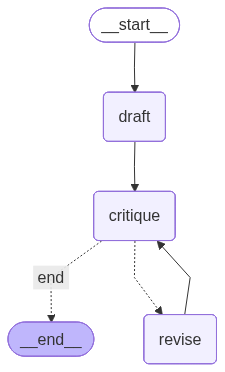

In [18]:
app

Now invoke it on the same drafting task and print the result.

In [19]:
initial: RevisionState = {
    'task': DRAFT_TASK, 'prs': MERGED_PRS,
    'draft': '', 'revised': '',
    'critique': None, 'verdict': None,
    'iteration': 0, 'status': 'drafting',
}
graph_result = app.invoke(initial, config={'recursion_limit': 25})

print('=== STATEGRAPH CAPSTONE ===')
print('iterations    :', graph_result['iteration'])
print('last severity :', graph_result['critique']['severity'] if graph_result.get('critique') else 'n/a')
print('---- FINAL GRAPH DRAFT ----')
print(graph_result['revised'])

=== STATEGRAPH CAPSTONE ===
iterations    : 0
last severity : minor
---- FINAL GRAPH DRAFT ----
- PR-101: Introduced streaming responses for the /chat endpoint to enhance real-time communication.
- PR-104: Resolved race condition in cache invalidation during logout for improved stability.
- PR-107: Upgraded to pydantic 2.7 and migrated validators for better performance.
- PR-112: Launched /admin/usage dashboard displaying per-tenant token counts for detailed usage insights.


## Side-by-side: bare vs critic-loop vs verifier-loop

Now let's run all three pipelines on the SAME draft task and read the quality delta. The drafter LLM, the prompt, and the PR list are identical across runs. The only thing that varies is who decides when to stop.

Now, we will
- run `bare_draft`, `critic_loop`, and `verifier_loop` on the same task,
- print each output with truncated bodies,
- name what self-correction bought us: critic raises subjective quality, verifier enforces hard constraints.

In [20]:
runs = [
    ('BARE DRAFT',     bare_draft(DRAFT_TASK, MERGED_PRS)),
    ('CRITIC LOOP',    critic_loop(DRAFT_TASK, MERGED_PRS)['final_draft']),
    ('VERIFIER LOOP',  verifier_loop(DRAFT_TASK, MERGED_PRS)['final_draft']),
]

for label, draft in runs:
    print(f'\n---- {label} ----')
    print(draft[:240] + ('...' if len(draft) > 240 else ''))

print('\n=== self-correction summary ===')
print('  bare      : no quality gate, no correctness gate.')
print('  critic    : raises SUBJECTIVE quality (tone, ordering); does not enforce hard constraints.')
print('  verifier  : enforces HARD constraints (bullet count, PR ids); does not polish.')


---- BARE DRAFT ----
- PR-101: Introduced streaming responses for the /chat endpoint to enhance real-time communication.
- PR-104: Resolved race condition in cache invalidation during logout for improved stability.
- PR-107: Upgraded to pydantic 2.7 and migrate...

---- CRITIC LOOP ----
- PR-101: Introduced streaming responses for the /chat endpoint to enhance real-time communication.
- PR-104: Resolved race condition in cache invalidation during user logout for improved stability.
- PR-107: Upgraded to pydantic 2.7 and mi...

---- VERIFIER LOOP ----
- PR-101: Added streaming responses to /chat endpoint for real-time communication.
- PR-104: Fixed race condition in cache invalidation on logout.
- PR-107: Bumped pydantic to 2.7 and migrated validators.
- PR-112: Introduced /admin/usage d...

=== self-correction summary ===
  bare      : no quality gate, no correctness gate.
  critic    : raises SUBJECTIVE quality (tone, ordering); does not enforce hard constraints.
  verifier  : enforc

**Critic vs verifier.** Both pipelines call the same drafter LLM. The critic raises subjective quality but lets a wrong-shape draft through; the verifier enforces hard constraints but does not polish. In production you compose both, critic first to push quality up, verifier last as the hard gate before shipping.

### Designing critic and verifier agents
- Critic must produce a rewrite directive, not just a score. A score-only critic generates feedback no one acts on. Always include a `suggestions` (or equivalent) field, and always feed it into the revise step when severity is major.
- Verifier should be deterministic where possible. If a constraint can be expressed as code (regex, JSON-schema, `len(bullets) == 4`), express it as code. Reserve LLM verifiers for cases where rule-based verification is impractical.
- Use `passed: bool`, never `pass: bool`. `pass` is a Python keyword and Pydantic will reject it as a field name.
- Set `temperature=0` on every critic / verifier call so verdicts are reproducible. Reserve temperature variation for the drafter, never the gate.

### Running self-correction loops in production
- Always cap revisions with a `MAX_REVISIONS` constant. Self-correction loops have the same runaway-cost failure mode as any agent loop. 2-3 revisions is enough for most tasks; beyond that you get diminishing returns and rising cost.
- Compose critic and verifier; do not substitute. A critic-only pipeline ships pretty-but-wrong drafts. A verifier-only pipeline ships ugly-but-correct drafts. Layered, you get correct AND polished.
- Log every iteration's critique / verdict to the same audit trail. Debugging a stuck loop is much easier when you can read the structured feedback that drove each revise step.